# Using Ragas to Evaluate a RAG Application built with LangChain and LangGraph

In the following notebook, we'll be looking at how [Ragas](https://github.com/explodinggradients/ragas) can be helpful in a number of ways when looking to evaluate your RAG applications!

While this example is rooted in LangChain/LangGraph - Ragas is framework agnostic (you don't even need to be using a framework!).

- 🤝 Breakout Room #1
  1. Task 1: Installing Required Libraries
  2. Task 2: Set Environment Variables
  3. Task 3: Synthetic Dataset Generation for Evaluation using Ragas
  4. Task 4: Evaluating our Pipeline with Ragas
  5. Task 6: Making Adjustments and Re-Evaluating

But first! Let's set some dependencies!

## Dependencies and API Keys:

We'll also need to provide our API keys.

First, OpenAI's for our LLM/embedding model combination!

In [1]:
import os
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Please enter your OpenAI API key!")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - which should hopefull be familiar at this point since it's our Loan Data use-case!

Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [2]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [3]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

In [4]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/38 [00:00<?, ?it/s]

Property 'summary' already exists in node 'f01c0e'. Skipping!
Property 'summary' already exists in node '2d3bc9'. Skipping!
Property 'summary' already exists in node '1adfe1'. Skipping!
Property 'summary' already exists in node '965392'. Skipping!
Property 'summary' already exists in node '9bf18d'. Skipping!
Property 'summary' already exists in node 'febe38'. Skipping!
Property 'summary' already exists in node '77aeb7'. Skipping!
Property 'summary' already exists in node '55e6e5'. Skipping!
Property 'summary' already exists in node 'ee59d9'. Skipping!
Property 'summary' already exists in node '8bf33b'. Skipping!
Property 'summary' already exists in node 'e12db2'. Skipping!
Property 'summary' already exists in node 'f97d51'. Skipping!
Property 'summary' already exists in node 'dea9ab'. Skipping!
Property 'summary' already exists in node '06eac7'. Skipping!
Property 'summary' already exists in node '27ffc6'. Skipping!
Property 'summary' already exists in node 'aaa7be'. Skipping!
Property

...

Property 'summary_embedding' already exists in node 'f97d51'. Skipping!
Property 'summary_embedding' already exists in node 'e12db2'. Skipping!
Property 'summary_embedding' already exists in node 'fa30a3'. Skipping!
Property 'summary_embedding' already exists in node '965392'. Skipping!
Property 'summary_embedding' already exists in node 'febe38'. Skipping!
Property 'summary_embedding' already exists in node '8bf33b'. Skipping!
Property 'summary_embedding' already exists in node 'aaa7be'. Skipping!
Property 'summary_embedding' already exists in node 'ee59d9'. Skipping!
Property 'summary_embedding' already exists in node '27ffc6'. Skipping!
Property 'summary_embedding' already exists in node '55e6e5'. Skipping!
Property 'summary_embedding' already exists in node 'f01c0e'. Skipping!
Property 'summary_embedding' already exists in node '06eac7'. Skipping!
Property 'summary_embedding' already exists in node '2d3bc9'. Skipping!
Property 'summary_embedding' already exists in node '1adfe1'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [5]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,"How has the rapid global adpotion of ChatGPT, ...",[Introduction ChatGPT launched in November 202...,"ChatGPT, launched in November 2022, experience...",single_hop_specifc_query_synthesizer
1,Could you provide a detailed breakdown of the ...,[Month Non-Work (M) (%) Work (M) (%) Total Mes...,"In Jun 2025, the total number of messages was ...",single_hop_specifc_query_synthesizer
2,What was the most common use case for work-rel...,[Table 1: ChatGPT daily message counts (millio...,"In June 2025, Writing was the most common use ...",single_hop_specifc_query_synthesizer
3,"According to the provided context, which occup...",[Variation by Occupation Figure 23 presents va...,SOC2 code 19 corresponds to engineering and sc...,single_hop_specifc_query_synthesizer
4,Based on the message volume statistics for Cha...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"According to the message volume statistics, to...",multi_hop_abstract_query_synthesizer
5,how much chatgpt message volume grow year over...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,chatgpt total messages grew from 451 million i...,multi_hop_abstract_query_synthesizer
6,How does the growth in non-work messages on Ch...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"Between June 2024 and June 2025, non-work mess...",multi_hop_abstract_query_synthesizer
7,What do the message volume statistics show abo...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,The message volume statistics indicate that to...,multi_hop_abstract_query_synthesizer
8,How did the total number of ChatGPT messages a...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,"Between Jun 2024 and Jun 2025, the total numbe...",multi_hop_specific_query_synthesizer
9,How did the proportion of non-work versus work...,[<1-hop>\n\nConclusion This paper studies the ...,"Between June 2024 and June 2025, the proportio...",multi_hop_specific_query_synthesizer


## LangChain RAG

Now we'll construct our LangChain RAG, which we will be evaluating using the above created test data!

### R - Retrieval

Let's start with building our retrieval pipeline, which will involve loading the same data we used to create our synthetic test set above.

> NOTE: We need to use the same data - as our test set is specifically designed for this data.

In [6]:
path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

Now that we have our data loaded, let's split it into chunks!

In [7]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=0)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

3122

#### ❓ Question: 

What is the purpose of the `chunk_overlap` parameter in the `RecursiveCharacterTextSplitter`?

##### ✅ Answer:
It helps to maintain contextual continuity and semantic cohenerce between consecutive chunks this helps in responses being more informaed and accurate but has an overhead because now we need more chunks and more processing. 

Next up, we'll need to provide an embedding model that we can use to construct our vector store.

In [8]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can build our in memory QDrant vector store.

In [9]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data",
    embedding=embeddings,
)

We can now add our documents to our vector store.

In [10]:
_ = vector_store.add_documents(documents=split_documents)

Let's define our retriever.

In [11]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

Now we can produce a node for retrieval!

In [12]:
def retrieve(state):
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

### Augmented

Let's create a simple RAG prompt!

In [13]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

### Generation

We'll also need an LLM to generate responses - we'll use `gpt-4o-nano` to avoid using the same model as our judge model.

In [14]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

Then we can create a `generate` node!

In [15]:
def generate(state):
  docs_content = "\n\n".join(doc.page_content for doc in state["context"])
  messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
  response = llm.invoke(messages)
  return {"response" : response.content}

### Building RAG Graph with LangGraph

Let's create some state for our LangGraph RAG graph!

In [16]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

Now we can build our simple graph!

> NOTE: We're using `add_sequence` since we will always move from retrieval to generation. This is essentially building a chain in LangGraph.

In [17]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

Let's do a test to make sure it's doing what we'd expect.

In [18]:
response = graph.invoke({"question" : "What are the different kinds of loans?"})

In [19]:
response["response"]

'The provided context does not contain specific information about the different kinds of loans.'

## Evaluating the App with Ragas

Now we can finally do our evaluation!

We'll start by running the queries we generated usign SDG above through our application to get context and responses.

In [20]:
for test_row in dataset:
  response = graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

In [21]:
dataset.samples[0].eval_sample.response

"According to recent studies, the rapid global adoption of ChatGPT, the first mass-market chatbot, has significantly influenced how users in knowledge-intensive fields utilize this LLM-based AI tool for productivity and information tasks. Users increasingly incorporate ChatGPT into their workflows to enhance efficiency and access information more effectively. To understand these usage patterns, researchers have conducted large-scale surveys on chatbot use and have analyzed ChatGPT message content via various methods. These approaches involve classifying and analyzing the types of messages sent by users to better understand their interactions and the specific ways they leverage the chatbot's capabilities."

Then we can convert that table into a `EvaluationDataset` which will make the process of evaluation smoother.

In [22]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

We'll need to select a judge model - in this case we're using the same model that was used to generate our Synthetic Data.

In [23]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))

Next up - we simply evaluate on our desired metrics!

In [ ]:
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

baseline_result = evaluate(
    dataset=evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
baseline_result

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

## Making Adjustments and Re-Evaluating

Now that we've got our baseline - let's make a change and see how the model improves or doesn't improve!

> NOTE: This will be using Cohere's Rerank model - please be sure to [sign-up for an API key!](https://docs.cohere.com/reference/about)

In [ ]:
os.environ["COHERE_API_KEY"] = getpass("Please enter your Cohere API key!")


We'll first set our retriever to return more documents, which will allow us to take advantage of the reranking.

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=30)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data_new_chunks",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data_new_chunks",
    embedding=embeddings,
)

_ = vector_store.add_documents(documents=split_documents)

adjusted_example_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

Reranking, or contextual compression, is a technique that uses a reranker to compress the retrieved documents into a smaller set of documents.

This is essentially a slower, more accurate form of semantic similarity that we use on a smaller subset of our documents.

In [ ]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_adjusted(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=adjusted_example_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

We can simply rebuild our graph with the new retriever!

In [ ]:
class AdjustedState(TypedDict):
  question: str
  context: List[Document]
  response: str

adjusted_graph_builder = StateGraph(AdjustedState).add_sequence([retrieve_adjusted, generate])
adjusted_graph_builder.add_edge(START, "retrieve_adjusted")
adjusted_graph = adjusted_graph_builder.compile()

In [ ]:
response = adjusted_graph.invoke({"question" : "What are the different kinds of loans?"})
response["response"]

'The provided context does not include information about the different kinds of loans.'

In [ ]:
import time
import copy

rerank_dataset = copy.deepcopy(dataset)

for test_row in rerank_dataset:
  response = adjusted_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  time.sleep(7) # To try to avoid rate limiting.

In [ ]:
rerank_dataset.samples[0].eval_sample.response

'ChatGPT was launched in November 2022.'

In [ ]:
rerank_evaluation_dataset = EvaluationDataset.from_pandas(rerank_dataset.to_pandas())

In [ ]:
rerank_result = evaluate(
    dataset=rerank_evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
rerank_result

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Exception raised in Job[25]: AttributeError('StringIO' object has no attribute 'statements')


{'context_recall': 0.6354, 'faithfulness': 0.9653, 'factual_correctness': 0.5962, 'answer_relevancy': 0.8204, 'context_entity_recall': 0.6010, 'noise_sensitivity_relevant': 0.1713}

In [ ]:
baseline_result

{'context_recall': 0.1250, 'faithfulness': 0.6360, 'factual_correctness': 0.4225, 'answer_relevancy': 0.2320, 'context_entity_recall': 0.2744, 'noise_sensitivity_relevant': 0.0625}

#### ❓ Question: 

Which system performed better, on what metrics, and why?

In [ ]:
##### ✅ Answer:
The reranked result was much better on all metrics. The baseline retriever in the rerank gathers  more context (here we use k=20 instead of 3) 
adn then cohere uses 5. The reranking does a deeper analysis and assigns a precise relevant score (using a cross-encoder) that can be sorted on and 
provides the most relevant results. 
With a bi-encoder  we create the vector embeddings without knowledge of the query. With rerankers, we are not pre-computing anything. 
Instead, we feed the query and a single other document into the transformer, running a whole transformer inference step, and outputting a single similarity score.
But it is computationally more expensive and hence is typically not run on the entire corpus. 

Please see the below visualization for the results. 

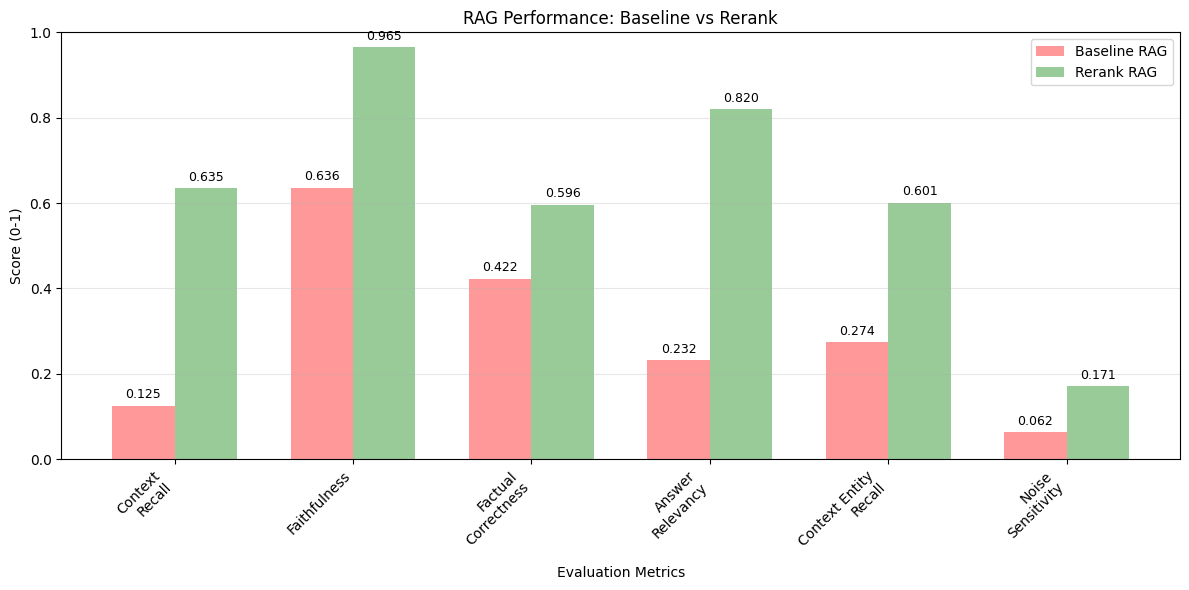

Baseline vs Rerank Results:
context_recall: 0.125 → 0.635 (+408.3%)
faithfulness: 0.636 → 0.965 (+51.8%)
factual_correctness: 0.422 → 0.596 (+41.1%)
answer_relevancy: 0.232 → 0.820 (+253.6%)
context_entity_recall: 0.274 → 0.601 (+119.1%)
noise_sensitivity_relevant: 0.062 → 0.171 (+174.0%)


In [ ]:
# Visualization: Baseline vs Rerank Results Comparison
import matplotlib.pyplot as plt
import numpy as np

# Extract results using the correct method
baseline_df = baseline_result.to_pandas()
rerank_df = rerank_result.to_pandas()

# Get mean scores for each metric
baseline_scores = [
    baseline_df['context_recall'].mean(),
    baseline_df['faithfulness'].mean(),
    baseline_df['factual_correctness'].mean(),
    baseline_df['answer_relevancy'].mean(),
    baseline_df['context_entity_recall'].mean(),
    baseline_df['noise_sensitivity_relevant'].mean()
]

rerank_scores = [
    rerank_df['context_recall'].mean(),
    rerank_df['faithfulness'].mean(),
    rerank_df['factual_correctness'].mean(),
    rerank_df['answer_relevancy'].mean(),
    rerank_df['context_entity_recall'].mean(),
    rerank_df['noise_sensitivity_relevant'].mean()
]

metrics = ['Context\nRecall', 'Faithfulness', 'Factual\nCorrectness', 
           'Answer\nRelevancy', 'Context Entity\nRecall', 'Noise\nSensitivity']

# Create bar chart
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, baseline_scores, width, label='Baseline RAG', alpha=0.8, color='#ff7f7f')
plt.bar(x + width/2, rerank_scores, width, label='Rerank RAG', alpha=0.8, color='#7fbf7f')

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score (0-1)')
plt.title('RAG Performance: Baseline vs Rerank')
plt.xticks(x, metrics, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 1)

# Add value labels on bars
for i, (baseline, rerank) in enumerate(zip(baseline_scores, rerank_scores)):
    plt.text(i - width/2, baseline + 0.01, f'{baseline:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, rerank + 0.01, f'{rerank:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print comparison
print("Baseline vs Rerank Results:")
metric_names = ['context_recall', 'faithfulness', 'factual_correctness', 
                'answer_relevancy', 'context_entity_recall', 'noise_sensitivity_relevant']
for metric, baseline, rerank in zip(metric_names, baseline_scores, rerank_scores):
    improvement = ((rerank - baseline) / baseline) * 100
    print(f"{metric}: {baseline:.3f} → {rerank:.3f} (+{improvement:.1f}%)")
